In [ ]:
# importy
import random
import matplotlib.pyplot as plt

In [ ]:
MOVES = ["R", "P", "S"]  # Rock, Paper, Scissors

In [ ]:
def get_winner(move1, move2):
    if move1 == move2:
        return 0  # remis

    wins = {("R", "S"), ("P", "R"), ("S", "P")}
    return 1 if (move1, move2) in wins else -1

def counter_move(move):
    match move:
        case "R":
            return "P"
        case "P":
            return "S"
        case "S":
            return "R"

In [ ]:
# Macierz przejść
transition_matrix = {
    "R": {"R": 0.3, "P": 0.4, "S": 0.3},
    "P": {"R": 0.4, "P": 0.2, "S": 0.4},
    "S": {"R": 0.8, "P": 0.1, "S": 0.1}
}

In [ ]:
class MarkovPlayer:
    def __init__(self, transition_matrix, initial_move=None):
        self.transition_matrix = transition_matrix
        self.last_move = initial_move or random.choice(MOVES)

    def choose_move(self):
        probs = self.transition_matrix[self.last_move]
        moves = list(probs.keys())
        weights = list(probs.values())

        next_move = random.choices(moves, weights=weights, k=1)[0]
        self.last_move = next_move
        return next_move, probs

In [ ]:
class BayesianLearningPlayer:
    def __init__(self, alpha=1.0):
        # Dirichlet prior
        self.counts = {
            m: {n: alpha for n in MOVES}
            for m in MOVES
        }
        self.last_opponent_move = None

    def update(self, prev_move, next_move):
        self.counts[prev_move][next_move] += 1

    def predict_next(self, last_move):
        row = self.counts[last_move]
        total = sum(row.values())
        return {m: row[m] / total for m in MOVES}

    def choose_move(self):
        if self.last_opponent_move is None:
            return random.choice(MOVES)

        probs = self.predict_next(self.last_opponent_move)
        predicted = max(probs, key=probs.get)

        return counter_move(predicted)

    def observe(self, opponent_move):
        if self.last_opponent_move is not None:
            self.update(self.last_opponent_move, opponent_move)
        self.last_opponent_move = opponent_move


In [ ]:
def play_game(player1, player2, rounds=100):
    score = 0
    cumulative_scores = []

    for i in range(rounds):
        # 1. wybór ruchów
        move1, probs1 = player1.choose_move()
        move2 = player2.choose_move()

        # 2. wynik
        result = get_winner(move1, move2)
        score += result
        cumulative_scores.append(score)

        # 3. uczenie (po rundzie)
        player2.observe(move1)

        print(f"Runda: {i+1}, Wynik: {result}")

    print("\n=== Wynik końcowy ===")
    if score > 0:
        print("Gracz 1 wygrywa")
    elif score < 0:
        print("Gracz 2 wygrywa")
    else:
        print("Remis")

    return cumulative_scores

In [ ]:
player1 = MarkovPlayer(transition_matrix)
player2 = BayesianLearningPlayer(alpha=1.0)

cumulative_scores = play_game(player1, player2, rounds=1000)

Runda: 1, Wynik: -1
Runda: 2, Wynik: -1
Runda: 3, Wynik: 1
Runda: 4, Wynik: -1
Runda: 5, Wynik: 1
Runda: 6, Wynik: 1
Runda: 7, Wynik: -1
Runda: 8, Wynik: -1
Runda: 9, Wynik: 1
Runda: 10, Wynik: -1
Runda: 11, Wynik: -1
Runda: 12, Wynik: 0
Runda: 13, Wynik: 1
Runda: 14, Wynik: 1
Runda: 15, Wynik: -1
Runda: 16, Wynik: -1
Runda: 17, Wynik: 0
Runda: 18, Wynik: -1
Runda: 19, Wynik: -1
Runda: 20, Wynik: 0
Runda: 21, Wynik: 1
Runda: 22, Wynik: -1
Runda: 23, Wynik: 0
Runda: 24, Wynik: -1
Runda: 25, Wynik: 1
Runda: 26, Wynik: -1
Runda: 27, Wynik: 0
Runda: 28, Wynik: 1
Runda: 29, Wynik: -1
Runda: 30, Wynik: 1
Runda: 31, Wynik: 1
Runda: 32, Wynik: 0
Runda: 33, Wynik: -1
Runda: 34, Wynik: -1
Runda: 35, Wynik: -1
Runda: 36, Wynik: -1
Runda: 37, Wynik: -1
Runda: 38, Wynik: 0
Runda: 39, Wynik: 1
Runda: 40, Wynik: 1
Runda: 41, Wynik: 0
Runda: 42, Wynik: -1
Runda: 43, Wynik: 1
Runda: 44, Wynik: -1
Runda: 45, Wynik: 0
Runda: 46, Wynik: 1
Runda: 47, Wynik: -1
Runda: 48, Wynik: -1
Runda: 49, Wynik: 0
Runda

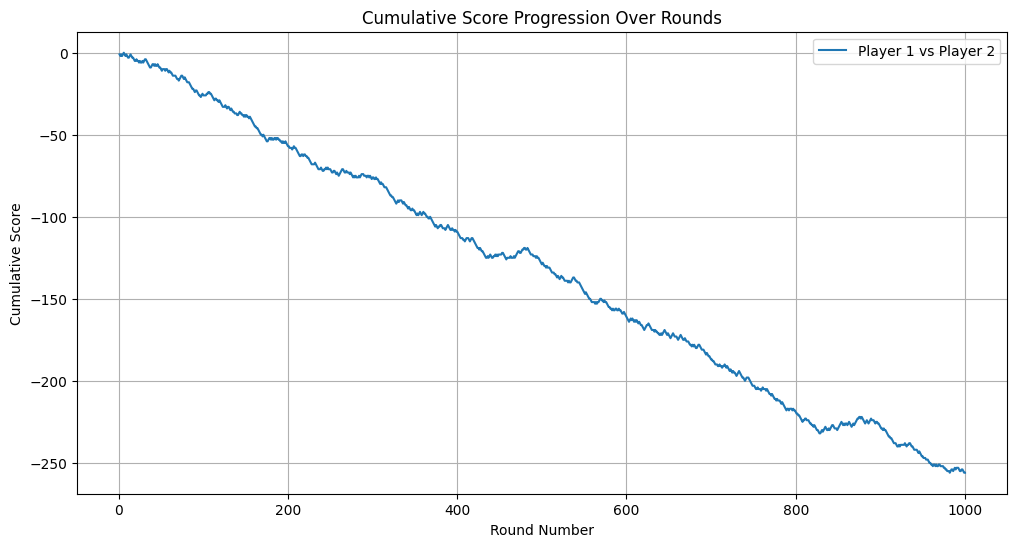

In [ ]:
rounds = 1000
round_numbers = list(range(1, rounds + 1))

plt.figure(figsize=(12, 6))
plt.plot(round_numbers, cumulative_scores, label='Player 1 vs Player 2')
plt.xlabel('Round Number')
plt.ylabel('Cumulative Score')
plt.title('Cumulative Score Progression Over Rounds')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
learned_transition_matrix = {
    m: player2.predict_next(m)
    for m in MOVES
}

print("\n--- Learned Transition Matrix (Formatted) ---")

header = [" "] + MOVES
print(f"{header[0]:<5} {' '.join(f'{m:<7}' for m in header[1:])}")

for from_move in MOVES:
    row_output = f"{from_move:<5}"
    for to_move in MOVES:
        probability = learned_transition_matrix[from_move][to_move]
        row_output += f"{probability:.4f}{' ':<2}"
    print(row_output)


--- Learned Transition Matrix (Formatted) ---
      R       P       S      
R    0.3004  0.4035  0.2961  
P    0.3919  0.2125  0.3956  
S    0.7634  0.1075  0.1290  
